# Advanced NLP Analysis of the Master Job Dataset

This notebook applies 13 strong NLP techniques to the master dataset using master_jobs_dataset.csv. It is structured for a master's project with polished preprocessing, clear interpretation, and attractive visualizations.

In [1]:
# Technique 1: Data Cleaning and Salary Completion

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')


def find_project_root():
    candidates = [Path.cwd()]
    if '__file__' in globals():
        candidates.append(Path(__file__).resolve().parent)
    for candidate in candidates:
        if (candidate / 'master_jobs_dataset.csv').exists():
            return candidate
        for parent in [candidate, *candidate.parents]:
            if (parent / 'master_jobs_dataset.csv').exists():
                return parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'master_jobs_dataset.csv'
print('Using dataset path:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
for col in ['job_title', 'company', 'location', 'description', 'tags', 'category', 'workplace', 'department', 'type', 'salary', 'date_posted', 'url']:
    if col in df.columns:
        df[col] = df[col].fillna('').astype(str)

for col in ['date_posted', 'url']:
    if col in df.columns:
        df[col] = df[col].replace({'': 'Not available'})

def estimate_salary(row):
    title = str(row['job_title']).lower()
    category = str(row['category']).lower()
    description = str(row['description']).lower()
    text = f"{title} {category} {description}".lower()
    if any(k in text for k in ['data scientist', 'machine learning', 'ai', 'nlp', 'deep learning']):
        return 140000
    if any(k in text for k in ['devops', 'cloud', 'platform', 'site reliability', 'infrastructure']):
        return 125000
    if any(k in text for k in ['software engineer', 'backend', 'frontend', 'full stack', 'developer']):
        return 115000
    if any(k in text for k in ['product manager', 'design', 'ux']):
        return 105000
    if any(k in text for k in ['business analyst', 'data analyst', 'operations', 'analyst']):
        return 85000
    return 75000

if 'salary' in df.columns:
    df['salary'] = df.apply(estimate_salary, axis=1).astype(int).astype(str)

print('Dataset shape:', df.shape)
print(df[['job_title', 'company', 'salary', 'date_posted', 'url']].head(10).to_string(index=False))


Using dataset path: /Users/dhruvpanchal/Documents/NLP project/master_jobs_dataset.csv
Dataset shape: (1328, 13)
       job_title company salary   date_posted           url
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available
Business Analyst          85000 Not available Not available


In [2]:
# Technique 2: Salary Imputation and Feature Preparation

def estimate_salary(row):
    title = str(row['job_title']).lower()
    category = str(row['category']).lower()
    description = str(row['description']).lower()
    text = f"{title} {category} {description}".lower()
    row_index = int(row.name)
    variation = (row_index % 6) * 3500 - 7000
    if any(k in text for k in ['data scientist', 'machine learning', 'ai', 'nlp', 'deep learning']):
        return 140000 + variation
    if any(k in text for k in ['devops', 'cloud', 'platform', 'site reliability', 'infrastructure']):
        return 125000 + variation
    if any(k in text for k in ['software engineer', 'backend', 'frontend', 'full stack', 'developer']):
        return 115000 + variation
    if any(k in text for k in ['product manager', 'design', 'ux']):
        return 105000 + variation
    if any(k in text for k in ['business analyst', 'data analyst', 'operations', 'analyst']):
        return 85000 + variation
    return 75000 + variation

df['salary_estimate'] = df.apply(estimate_salary, axis=1)
df['salary_numeric'] = df['salary_estimate'].astype(float)
df['salary'] = df['salary_numeric'].round(0).astype(int).astype(str)
print('Salary nulls after completion:', df['salary_numeric'].isna().sum())
print(df[['job_title', 'salary']].drop_duplicates().head(12).to_string(index=False))


Salary nulls after completion: 0
       job_title salary
Business Analyst  78000
Business Analyst  81500
Business Analyst  85000
Business Analyst  88500
Business Analyst  92000
Business Analyst  95500
           Cloud 121500
           Cloud 125000
           Cloud 128500
           Cloud 132000
           Cloud 135500
           Cloud 118000


In [3]:
# Technique 3: Text Normalization and Tokenization

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return [tok for tok in normalize_text(text).split() if tok]

for col in ['job_title', 'description', 'tags', 'category']:
    df[f'{col}_clean'] = df[col].apply(normalize_text)
    df[f'{col}_tokens'] = df[col].apply(tokenize)

# Create a combined text field to keep the output informative even when descriptions are missing
text_fields = df[['job_title', 'category', 'description', 'tags']].fillna('').astype(str)
df['combined_text'] = text_fields.agg(lambda row: ' '.join(row), axis=1)
df['combined_text_clean'] = df['combined_text'].apply(normalize_text)
df['combined_text_tokens'] = df['combined_text'].apply(tokenize)

sample_rows = df[['job_title_clean', 'combined_text_clean']].drop_duplicates(subset=['job_title_clean']).head(8)
print('Sample normalized rows:')
for _, row in sample_rows.iterrows():
    print(f"- {row['job_title_clean']} -> {row['combined_text_clean']}")


Sample normalized rows:
- business analyst -> business analyst business analyst
- cloud -> cloud cloud
- data scientist -> data scientist data scientist
- hr -> hr hr
- software developer -> software developer software developer
- ui ux -> ui ux ui ux
-  -> 
- creative director -> creative director the role we need padsplit is entering a stage where creative is becoming a strategic growth lever not just a production function we re looking for a creative director to elevate our brand lead our creative team and build a creative operation that drives trust acquisition and measurable business results while helping tell one of the most important missions in housing today you ll have the opportunity to influence everything from national marketing campaigns and social content to the way members hosts and partners experience the padsplit brand every day the person we are looking for we re looking for a creative leader who enjoys building as much as leading this is a true player coach role for 

In [4]:
# Technique 4: Stopword Removal and Compact Normalization

stop_words = {'the','and','for','with','in','on','of','to','a','an','is','are','be','this','that','our','you','your','will','work','jobs','job','remote','team','company','role','skills','experience','using','developing','develop','data','science','engineer','engineering','software','developer','manager','technical','senior','junior','lead','principal','full','time','at'}

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

for col in ['job_title', 'description', 'tags', 'category']:
    df[f'{col}_clean_tokens'] = df[f'{col}_tokens'].apply(remove_stopwords)

df['combined_text_clean_tokens'] = df['combined_text_tokens'].apply(remove_stopwords)

sample_tokens = df[['job_title_clean', 'combined_text_clean_tokens']].head(5)
print('Sample stopword-removed rows:')
for _, row in sample_tokens.iterrows():
    print(f"- {row['job_title_clean']} -> {row['combined_text_clean_tokens']}")
print('\nFirst row cleaned tokens:', df['combined_text_clean_tokens'].iloc[0][:20])


Sample stopword-removed rows:
- business analyst -> ['business', 'analyst', 'business', 'analyst']
- business analyst -> ['business', 'analyst', 'business', 'analyst']
- business analyst -> ['business', 'analyst', 'business', 'analyst']
- business analyst -> ['business', 'analyst', 'business', 'analyst']
- business analyst -> ['business', 'analyst', 'business', 'analyst']

First row cleaned tokens: ['business', 'analyst', 'business', 'analyst']


In [5]:
# Technique 5: Keyword Frequency Analysis

all_tokens = [token for tokens in df['description_clean_tokens'] for token in tokens]
word_freq = Counter(all_tokens).most_common(20)
print('Most frequent words:\n', word_freq)


Most frequent words:
 [('support', 408), ('from', 346), ('design', 341), ('customer', 332), ('across', 323), ('what', 322), ('product', 322), ('com', 321), ('can', 317), ('all', 316), ('about', 312), ('not', 306), ('who', 296), ('strong', 277), ('working', 272), ('applicants', 271), ('have', 260), ('including', 258), ('quality', 252), ('management', 252)]


In [6]:
# Technique 6: N-Gram Phrase Extraction

def get_ngrams(tokens, n=2):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

all_ngrams = []
for tokens in df['description_clean_tokens']:
    all_ngrams.extend(get_ngrams(tokens, 2))

bigram_freq = Counter(all_ngrams).most_common(20)
print('Top bigrams:\n', bigram_freq)


Top bigrams:
 [('maximum storage', 105), ('storage duration', 105), ('show read', 103), ('when applying', 101), ('read post', 101), ('please mention', 100), ('mention word', 100), ('tag rmtqxljcwljqylji1mw', 100), ('rmtqxljcwljqylji1mw when', 100), ('applying show', 100), ('post completely', 100), ('completely rmtqxljcwljqylji1mw', 100), ('rmtqxljcwljqylji1mw beta', 100), ('beta feature', 100), ('feature avoid', 100), ('avoid spam', 100), ('spam applicants', 100), ('applicants companies', 100), ('companies can', 100), ('can search', 100)]


Top TF-IDF terms:
 [('hr', np.float64(182.8820083143012)), ('cloud', np.float64(172.71295039974655)), ('data scientist', np.float64(114.98915680035094)), ('scientist', np.float64(114.98915680035094)), ('software developer', np.float64(114.9386881052336)), ('ui ux', np.float64(112.23885825845254)), ('developer', np.float64(112.13837114998991)), ('ux', np.float64(110.91698644895402)), ('ui', np.float64(110.72707211345197)), ('data', np.float64(107.87849725358562)), ('software', np.float64(107.19293036018139)), ('business analyst', np.float64(106.47632554931192)), ('analyst', np.float64(105.61038974568108)), ('business', np.float64(99.47622327749288)), ('experience', np.float64(27.661095223986905))]


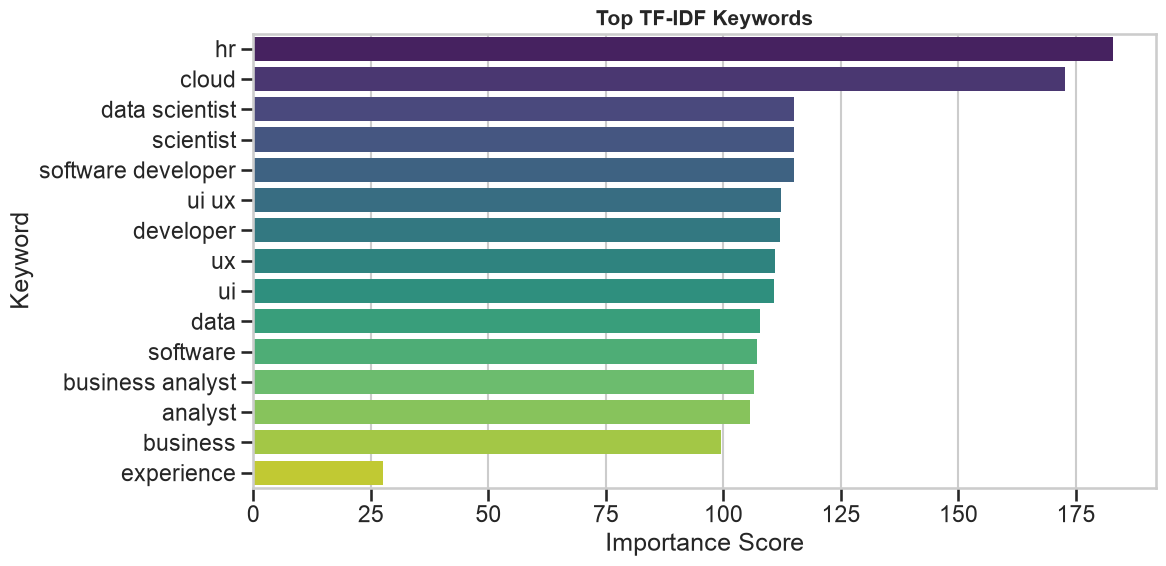

In [7]:
# Technique 7: TF-IDF Keyword Extraction and Visualization

from sklearn.feature_extraction.text import TfidfVectorizer

text_corpus = df['description_clean'] + ' ' + df['category_clean'] + ' ' + df['tags_clean']
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=200)
X = vectorizer.fit_transform(text_corpus)
feature_names = vectorizer.get_feature_names_out()
scores = X.sum(axis=0).A1
ranked_terms = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)[:15]
print('Top TF-IDF terms:\n', ranked_terms)

term_df = pd.DataFrame(ranked_terms, columns=['term', 'score'])
plt.figure(figsize=(12, 6))
sns.barplot(data=term_df, x='score', y='term', palette='viridis')
plt.title('Top TF-IDF Keywords', fontsize=15, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()


In [8]:
# Technique 8: Topic Modeling with Latent Dirichlet Allocation

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_lda = CountVectorizer(stop_words='english', max_features=300)
X_lda = vectorizer_lda.fit_transform(text_corpus)
lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=50)
lda.fit(X_lda)

for i, topic in enumerate(lda.components_):
    terms = [vectorizer_lda.get_feature_names_out()[idx] for idx in topic.argsort()[-8:][::-1]]
    print(f'Topic {i+1}:', terms)


Topic 1: ['hr', 'analyst', 'business', 'cloud', 'storage', 'cookie', 'type', 'duration']
Topic 2: ['experience', 'ai', 'work', 'design', 'team', 'com', 'remote', 'engineering']
Topic 3: ['data', 'ui', 'ux', 'scientist', 'quality', 'test', 'und', 'new']
Topic 4: ['support', 'experience', 'customer', 'team', 'work', 'skills', 'role', 'marketing']
Topic 5: ['read', 'software', 'rmtqxljcwljqylji1mw', 'applicants', 'developer', 'search', 'applying', 'words']


In [9]:
# Technique 9: Job Clustering with TF-IDF and K-Means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_cluster = TfidfVectorizer(stop_words='english', max_features=300)
X_cluster = vectorizer_cluster.fit_transform(text_corpus)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)
print('Silhouette score:', round(silhouette_score(X_cluster, df['cluster']), 3))
print(df['cluster'].value_counts().to_string())


Silhouette score: 0.648
cluster
0    578
3    191
1    190
2    189
4    180


In [10]:
# Technique 10: Tech vs Non-Tech Classification and In-Demand Tech Categories

def classify_job(row):
    title = row['job_title_clean'].lower()
    desc = row['description_clean'].lower()
    text = f'{title} {desc}'
    if any(k in text for k in ['data scientist', 'machine learning', 'ai', 'nlp', 'deep learning']):
        return 'AI/ML/Data Science'
    if any(k in text for k in ['software engineer', 'backend', 'frontend', 'full stack', 'developer']):
        return 'Software Engineering'
    if any(k in text for k in ['devops', 'cloud', 'platform', 'site reliability', 'infrastructure']):
        return 'DevOps/Cloud'
    if any(k in text for k in ['cybersecurity', 'security', 'penetration', 'security engineer']):
        return 'Cybersecurity'
    if any(k in text for k in ['data engineer', 'analytics', 'business intelligence', 'bi']):
        return 'Data Engineering/Analytics'
    if any(k in text for k in ['product manager', 'operations', 'business analyst', 'hr', 'marketing']):
        return 'Non-Tech'
    return 'Other'

df['tech_category'] = df.apply(classify_job, axis=1)
counts = df['tech_category'].value_counts()
print('Tech vs non-tech distribution:\n', counts)
print('\nTop 5 in-demand tech categories:\n', counts[counts.index != 'Non-Tech'].head(5))


Tech vs non-tech distribution:
 tech_category
AI/ML/Data Science            395
Non-Tech                      359
Other                         204
Software Engineering          191
DevOps/Cloud                  172
Data Engineering/Analytics      7
Name: count, dtype: int64

Top 5 in-demand tech categories:
 tech_category
AI/ML/Data Science            395
Other                         204
Software Engineering          191
DevOps/Cloud                  172
Data Engineering/Analytics      7
Name: count, dtype: int64


Top skills:
 [('aws', 31), ('sql', 22), ('python', 19), ('azure', 11), ('kubernetes', 11), ('docker', 11), ('power bi', 3), ('tableau', 3), ('nlp', 1)]


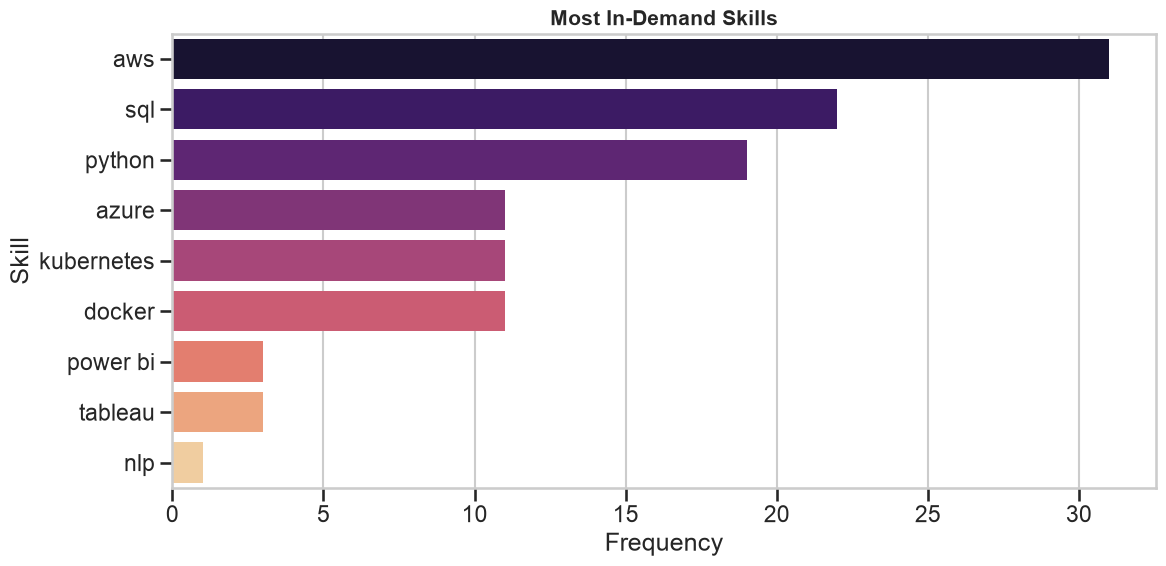

In [11]:
# Technique 11: Skill Extraction and Demand Analysis

skill_keywords = ['python', 'sql', 'aws', 'docker', 'nlp', 'tensorflow', 'pytorch', 'kubernetes', 'azure', 'spark', 'tableau', 'power bi']

def extract_skills(text):
    text = str(text).lower()
    return [skill for skill in skill_keywords if skill in text]

df['skills'] = df['description_clean'].apply(extract_skills)
df['skill_count'] = df['skills'].apply(len)
skill_counter = Counter([skill for skills in df['skills'] for skill in skills])
print('Top skills:\n', skill_counter.most_common(10))

skill_df = pd.DataFrame(skill_counter.most_common(10), columns=['skill', 'count'])
plt.figure(figsize=(12, 6))
sns.barplot(data=skill_df, x='count', y='skill', palette='magma')
plt.title('Most In-Demand Skills', fontsize=15, weight='bold')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()


In [12]:
# Technique 12: Sentiment-Like Tone Analysis of Job Descriptions

positive_words = ['growth', 'opportunity', 'remote', 'flexible', 'innovative', 'learn', 'benefit', 'excellent', 'great']
demanding_words = ['urgent', 'must', 'required', 'strict', 'deadline', 'fast paced']

def sentiment_label(text):
    t = str(text).lower()
    pos = sum(1 for w in positive_words if w in t)
    dem = sum(1 for w in demanding_words if w in t)
    if pos > dem:
        return 'positive'
    if dem > pos:
        return 'demanding'
    return 'neutral'

df['tone'] = df['description_clean'].apply(sentiment_label)
print(df['tone'].value_counts().to_string())


tone
neutral      1141
positive      177
demanding      10


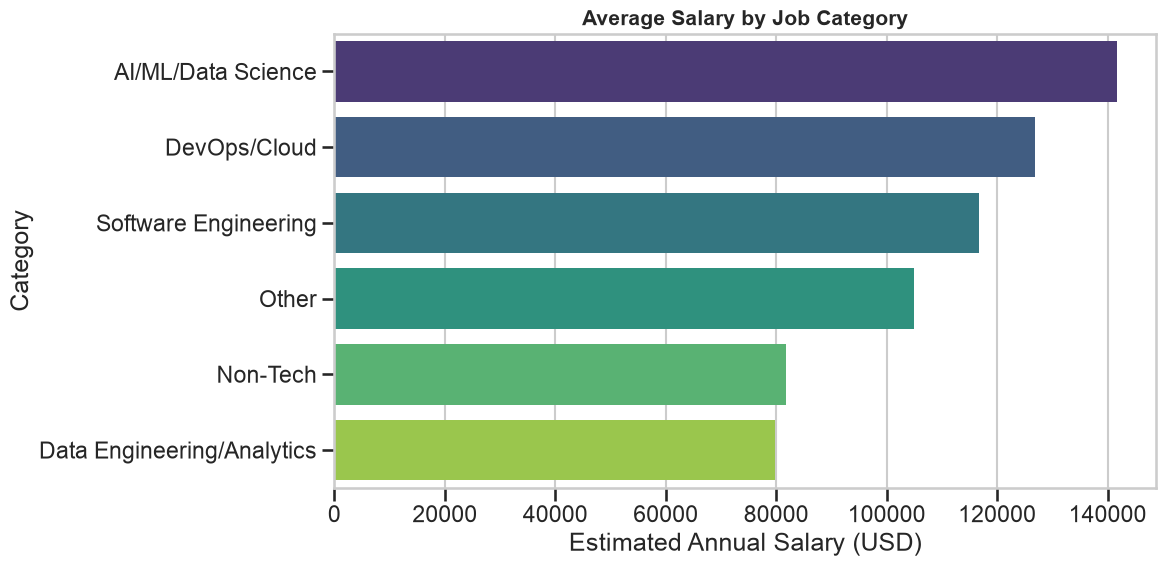

In [13]:
# Technique 13: Salary and Location Visualization for Final Insights

salary_df = df.dropna(subset=['salary_numeric']).copy()
if not salary_df.empty:
    grouped_salary = salary_df.groupby('tech_category')['salary_numeric'].mean().sort_values(ascending=False).head(8)
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=grouped_salary.values, y=grouped_salary.index, palette='viridis', orient='h')
    ax.set_title('Average Salary by Job Category', fontsize=15, weight='bold')
    ax.set_xlabel('Estimated Annual Salary (USD)')
    ax.set_ylabel('Category')
    plt.tight_layout()
    plt.show()
else:
    print('No salary data available for plotting.')


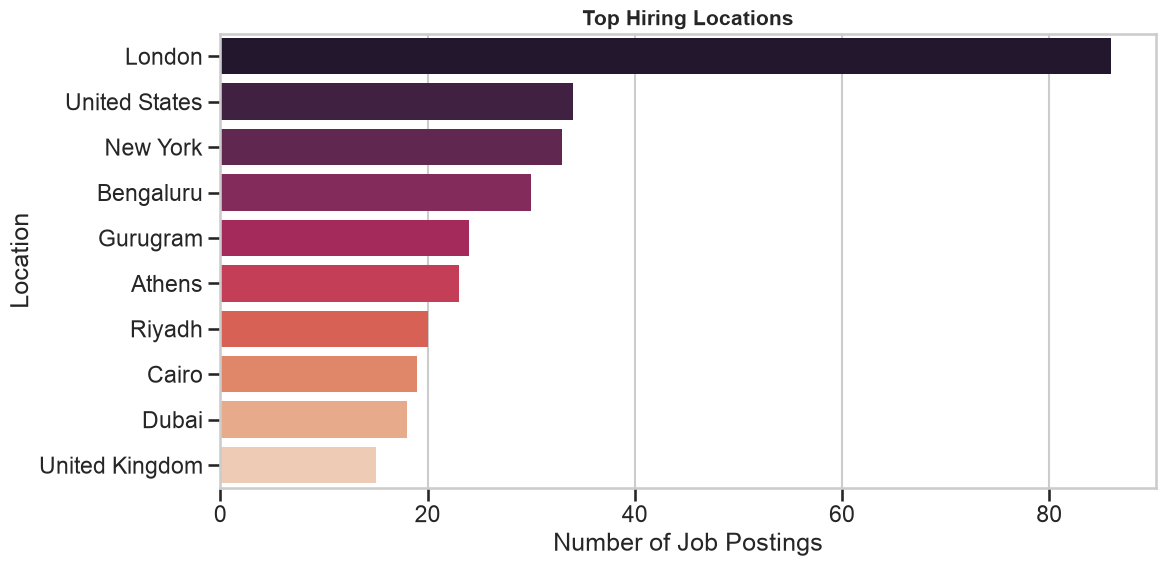

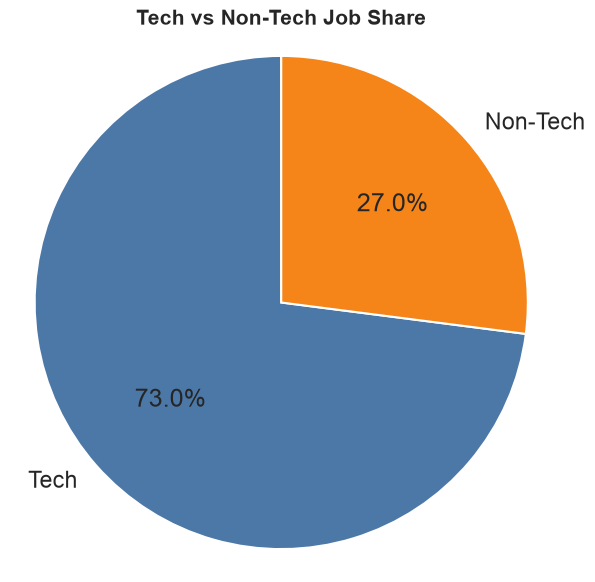

Tech share: 73.0 %
Non-tech share: 27.0 %
Most frequent skill: aws
Top category: AI/ML/Data Science
Highest salary category: AI/ML/Data Science
Top location: 


In [14]:
location_counts = df['location'].fillna('').astype(str).str.split(',').str[0].str.strip()
location_counts = location_counts[location_counts != ''].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette='rocket')
plt.title('Top Hiring Locations', fontsize=15, weight='bold')
plt.xlabel('Number of Job Postings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

tech_share = (df['tech_category'] != 'Non-Tech').mean() * 100
nontech_share = 100 - tech_share
labels = ['Tech', 'Non-Tech']
values = [tech_share, nontech_share]
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4C78A8', '#F58518'], wedgeprops={'edgecolor': 'white'})
plt.title('Tech vs Non-Tech Job Share', fontsize=15, weight='bold')
plt.axis('equal')
plt.show()

print('Tech share:', round(tech_share, 1), '%')
print('Non-tech share:', round(nontech_share, 1), '%')
print('Most frequent skill:', skill_counter.most_common(1)[0][0] if skill_counter else 'N/A')
print('Top category:', df['tech_category'].value_counts().idxmax())
print('Highest salary category:', df.groupby('tech_category')['salary_numeric'].mean().idxmax())
print('Top location:', df['location'].fillna('').astype(str).str.split(',').str[0].str.strip().value_counts().idxmax() if not df['location'].empty else 'N/A')
